In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.tree import export_text

In [2]:
drums = pd.read_csv('/Users/cody/Documents/Fall 2024 Classes Current/DSCI 445 Statistical Machine Learning/sample_features_balanced.csv')

## Initial Model

The drums data set is split into 75% training data, and 25% testing data, stratified by the classification ‘label’. A basic tree model is fit using the DecisionTreeClassifier()
function with a training set of 75%.

This initial model has an accuracy of 81% and correctly classifies:

19/26 Hats
20/26 Kicks
26/26 Rides
18/26 Snares

In [3]:
np.random.seed(445)

X = drums[['core_frequency', 'max_amplitude', 'average_activation', 'duration']]
y = drums['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)


In [4]:
tree_spec = DecisionTreeClassifier()
tree_spec.fit(X_train, y_train)

y_pred = tree_spec.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.81


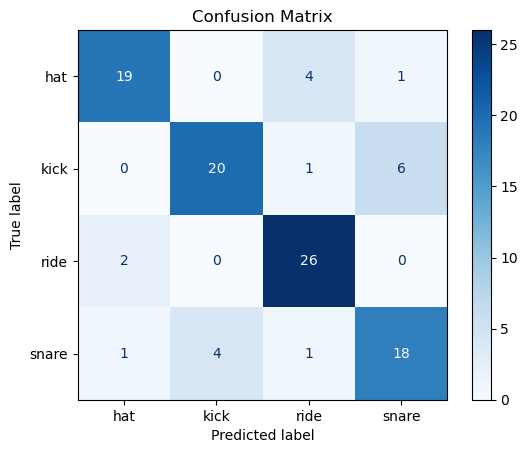

In [5]:
matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=tree_spec.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## Tuning Initial Tree Model

We used cross-validation to find the best cost_complexity parameter and tree depth.

Best CC Paremeter: 0.0069



##

In [6]:
np.random.seed(445)
path = tree_spec.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas


cv_scores = []


for ccp_alpha in ccp_alphas:
    tree_spec = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    scores = cross_val_score(tree_spec, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())


max_accuracy = max(cv_scores)
optimal_ccp_alpha = ccp_alphas[np.argmax(cv_scores)]

print(f"Maximum Accuracy: {max_accuracy:.2f}")
print(f"Optimal ccp_alpha: {optimal_ccp_alpha}")

Maximum Accuracy: 0.85
Optimal ccp_alpha: 0.006934812760055477


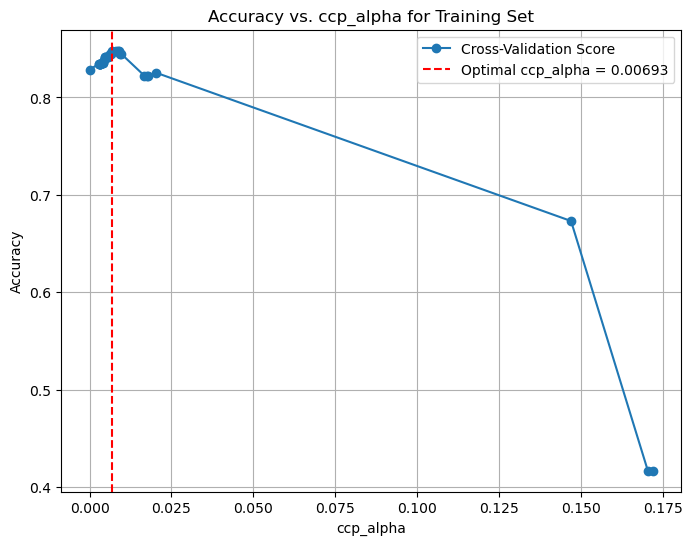

In [7]:
plt.figure(figsize=(8, 6))
plt.plot(ccp_alphas, cv_scores, marker='o', label='Cross-Validation Score')
plt.axvline(optimal_ccp_alpha, linestyle='--', color='r', label=f'Optimal ccp_alpha = {optimal_ccp_alpha:.5f}')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. ccp_alpha for Training Set')
plt.legend()
plt.grid(True)
plt.show()

## Final Tree Model

We refit the tree model using our tuned cost complexity parameter. With the new tuned paramter, we produced a model with a slightly higher level of accuracy. 
In the new model, we were more accurate at classifying every type of drum sound except for snares, which had a decreased level of accuracy between the initial and tuned models. 

In [8]:
tree_spec = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)


tree_spec.fit(X_train, y_train)


y_pred = tree_spec.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy with optimal ccp_alpha: {accuracy:.2f}")

Test Set Accuracy with optimal ccp_alpha: 0.82


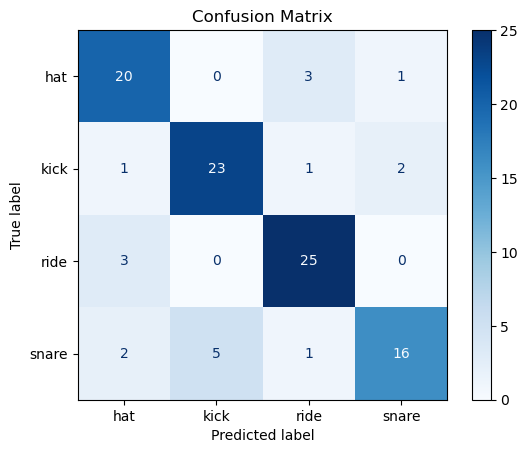

In [9]:
matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=tree_spec.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()